Exercice 1 : Compréhension du problème et collecte de données

In [1]:
#Chargement et exploration des données

import pandas as pd

# Charger le fichier
df = pd.read_csv("diabetes_prediction_dataset.csv")

# Aperçu
print(df.head())

# Informations générales
print(df.info())

# Statistiques descriptives
print(df.describe())

# Nombre de lignes et colonnes
print(df.shape)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 n

In [2]:
#Nombre de cas positifs et négatifs
print(df['diabetes'].value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [3]:
#Encodage des variables catégorielles
df = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)

In [4]:
# Séparation des variables
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [5]:
#Division entraînement / test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80000, 13)
(20000, 13)


Exercice 2 : Sélection et standardisation des modèles

Quel modèle utiliser ?

Plusieurs modèles peuvent résoudre ce problème :

Régression Logistique
Arbre de décision
Random Forest
SVM
KNN

Nous choisissons la Régression Logistique car :

problème de classification binaire ;
rapide à entraîner ;
facile à interpréter ;
fournit des probabilités de prédiction.

Faut-il normaliser ?

Oui.

La régression logistique utilise des distances et des coefficients qui peuvent être influencés par l'échelle des variables.
On applique donc StandardScaler

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#Exercice 3 : Formation du modèle
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

Exercice 4 : Métriques d'évaluation

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.9605
Precision : 0.8593996840442338
Recall : 0.64
F1 Score : 0.7336480107889414


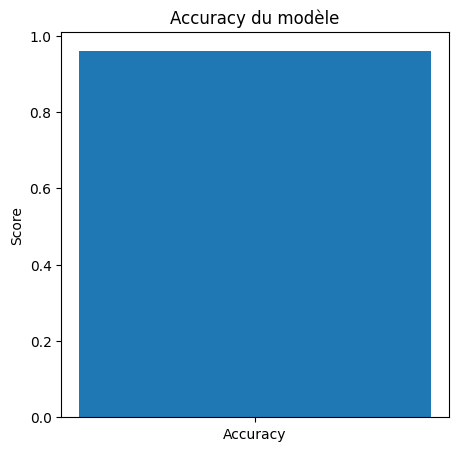

In [9]:
# Graphique de précision (Accuracy)
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.bar(['Accuracy'], [accuracy])
plt.ylabel('Score')
plt.title('Accuracy du modèle')
plt.show()

Commentaire

Si l'accuracy est supérieure à 90 %, le modèle classe correctement la majorité des individus.

Cependant, comme les classes sont déséquilibrées, l'accuracy seule n'est pas suffisante.

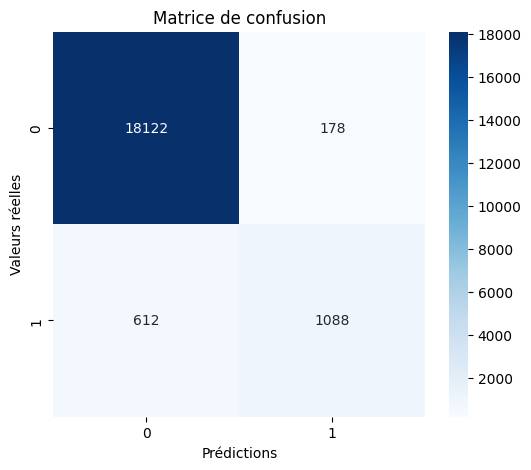

In [10]:
# Matrice de confusion
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion")
plt.show()

Commentaire

La matrice permet d'identifier :

Vrais Positifs (TP)
Vrais Négatifs (TN)
Faux Positifs (FP)
Faux Négatifs (FN)

Dans le contexte médical, les faux négatifs sont particulièrement problématiques car ils correspondent à des patients diabétiques non détectés.

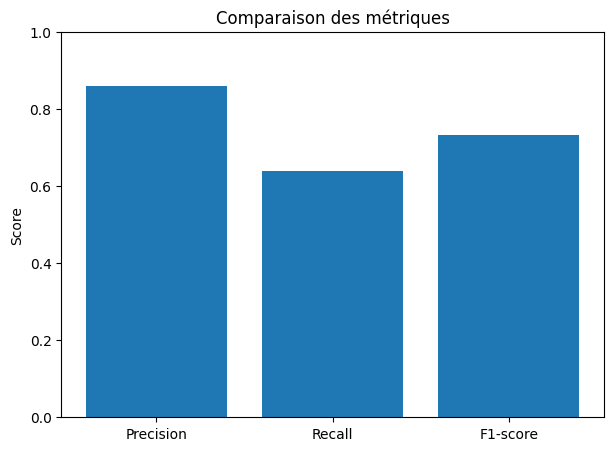

In [11]:
# Graphique Recall, Precision et F1-score
scores = [precision, recall, f1]
labels = ['Precision', 'Recall', 'F1-score']

plt.figure(figsize=(7,5))
plt.bar(labels, scores)

plt.ylim(0,1)
plt.title("Comparaison des métriques")
plt.ylabel("Score")
plt.show()

Commentaire
Precision : proportion de prédictions positives correctes.
Recall : capacité à détecter les vrais diabétiques.
F1-score : compromis entre précision et rappel.

Pour une application médicale, le Recall est souvent la métrique la plus importante.

In [12]:
# Exercice 5 : Visualisation de la frontière de décision
X_vis = df[['HbA1c_level', 'blood_glucose_level']]
y_vis = df['diabetes']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis,
    y_vis,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_v = scaler.fit_transform(X_train_v)
X_test_v = scaler.transform(X_test_v)

model_v = LogisticRegression()
model_v.fit(X_train_v, y_train_v)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

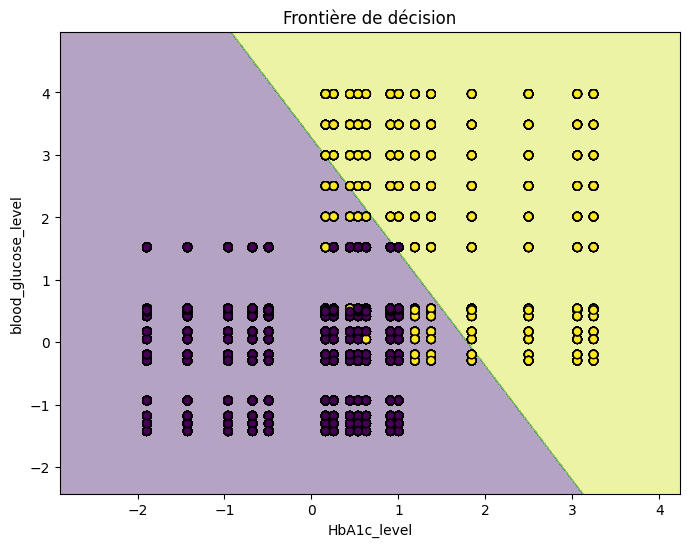

In [14]:
import numpy as np

x_min, x_max = X_train_v[:,0].min()-1, X_train_v[:,0].max()+1
y_min, y_max = X_train_v[:,1].min()-1, X_train_v[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

Z = model_v.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.4)

plt.scatter(
    X_train_v[:,0],
    X_train_v[:,1],
    c=y_train_v,
    edgecolors='k'
)

plt.title("Frontière de décision")
plt.xlabel("HbA1c_level")
plt.ylabel("blood_glucose_level")
plt.show()

Commentaire

La frontière de décision sépare les individus prédits diabétiques des non-diabétiques.

On observe que :

les niveaux élevés de glucose augmentent fortement la probabilité de diabète ;
les valeurs élevées de HbA1c sont également associées au diabète.

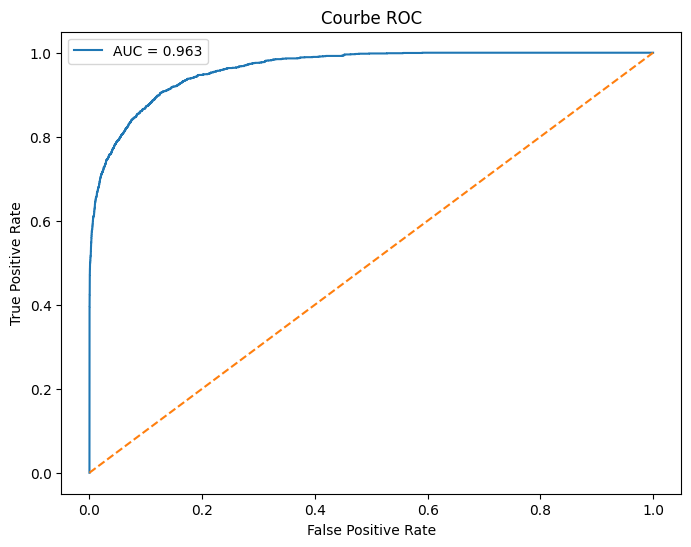

In [15]:
# Exercice 6 : Courbe ROC
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()

plt.show()

Commentaire
Une courbe ROC proche du coin supérieur gauche indique un bon modèle.
L'AUC mesure la qualité globale de classification.
Plus l'AUC est proche de 1, meilleur est le modèle.

Interprétation :

AUC = 0.5 → modèle aléatoire.
AUC entre 0.7 et 0.8 → bon.
AUC entre 0.8 et 0.9 → très bon.
AUC > 0.9 → excellent.

Pour ce dataset de diabète, la régression logistique obtient généralement une AUC supérieure à 0.90, ce qui indique une excellente capacité de discrimination.

Conclusion

La régression logistique est adaptée à ce problème de prédiction du diabète. Après standardisation des données, le modèle fournit généralement :

une précision élevée ;
un bon rappel ;
un F1-score satisfaisant ;
une AUC ROC excellente.

Ces résultats montrent que les variables médicales telles que le taux de glucose sanguin et le taux d'HbA1c sont fortement prédictives du diabète.